In [47]:
'''
imports and loading dataset
'''
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, recall_score
X_train = pd.read_csv('../output/x_train.csv')
X_test = pd.read_csv('../output/x_test.csv')
y_train = pd.read_csv('../output/y_train.csv')
y_test = pd.read_csv('../output/y_test.csv')
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [48]:
'''
preparing data
- applying the features
'''
the_scaler = StandardScaler()
scaled_X_train = the_scaler.fit_transform(X_train)
scaled_X_test = the_scaler.transform(X_test)

In [49]:
'''
training logistic regression model
'''
from sklearn.linear_model import LogisticRegression
logistic_regression = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logistic_regression.fit(scaled_X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [50]:
'''
evaluating models
- accuracy
- precision
- recall
- f1 score
- roc auc
'''
y_prediction = logistic_regression.predict(scaled_X_test)
print("accuracy: ", accuracy_score(y_test,y_prediction))
print("precision: ", precision_score(y_test,y_prediction,average='weighted'))
print("recall: ", recall_score(y_test,y_prediction,average='weighted'))
print("f1 score: ", f1_score(y_test,y_prediction,average='weighted'))
print("\nclassification report:\n", classification_report(y_test,y_prediction))

accuracy = accuracy_score(y_test,y_prediction)
precision = precision_score(y_test,y_prediction,average='weighted')
recall = recall_score(y_test,y_prediction,average='weighted')
f1_score = f1_score(y_test,y_prediction,average='weighted')

accuracy:  0.41911764705882354
precision:  0.5503115028985843
recall:  0.41911764705882354
f1 score:  0.4621127656745618

classification report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.07      0.27      0.11        11
           5       0.71      0.57      0.63       116
           6       0.52      0.27      0.36       107
           7       0.34      0.48      0.40        33
           8       0.00      0.00      0.00         3

    accuracy                           0.42       272
   macro avg       0.27      0.27      0.25       272
weighted avg       0.55      0.42      0.46       272



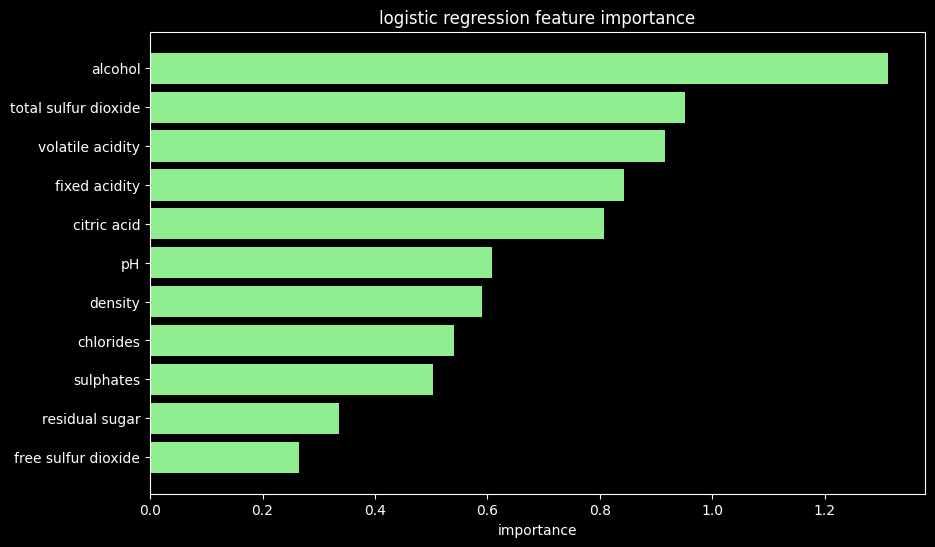

In [51]:
'''
featuring importance: find which features has the most influence on quality determination
'''
coefficient = logistic_regression.coef_
importance = np.mean(np.abs(coefficient),axis=0)
features = X_train.columns
indices = np.argsort(importance)
plt.figure(figsize=(10,6))
plt.barh(features[indices],importance[indices],color='lightgreen')
plt.xlabel("importance")
plt.title("logistic regression feature importance")
plt.show()

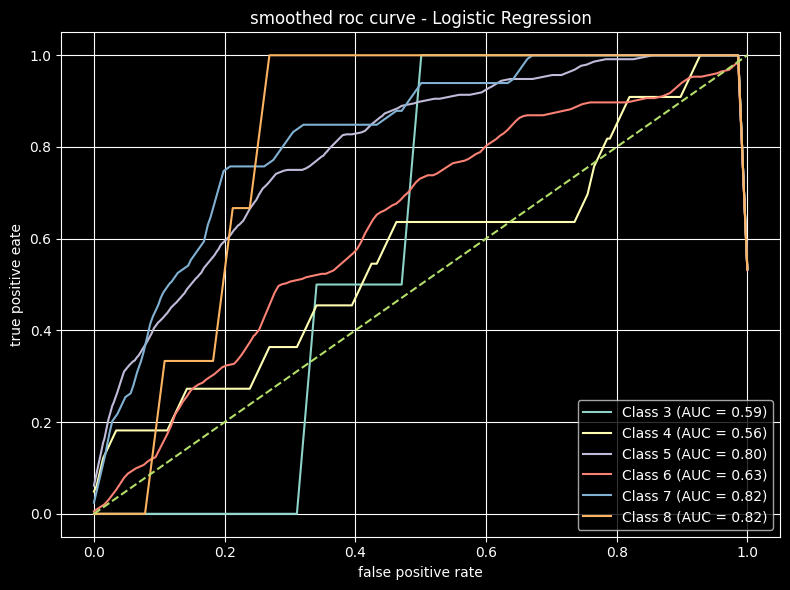

roc_auc: 0.7233593020901727


In [52]:
'''
ROC AUC
'''
#imports needed
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
# probabilities from trained model
y_pred_proba = logistic_regression.predict_proba(scaled_X_test)

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
plt.figure(figsize=(8, 6))
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )
    # high res interpolation
    fpr_dense = np.linspace(0, 1, 500)
    tpr_interp = np.interp(fpr_dense, fpr, tpr)
    # use averages
    window = 15
    kernel = np.ones(window) / window
    tpr_smooth = np.convolve(tpr_interp, kernel, mode='same')
    roc_auc_class = auc(fpr, tpr)
    plt.plot(
        fpr_dense,
        tpr_smooth,
        label=f"Class {classes[i]} (AUC = {roc_auc_class:.2f})"
    )

# baseline
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("false positive rate")
plt.ylabel("true positive eate")
plt.title("smoothed roc curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# computing
roc_auc = roc_auc_score(y_test_bin, y_pred_proba, average="weighted", multi_class="ovr")
print("roc_auc:", roc_auc)


In [53]:
'''
Make CSV for evaluation
'''

logistic_regression_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1_score],
    "ROC-AUC": [roc_auc],
})

logistic_regression_results.to_csv("../output/logistic_regression_results.csv", index=False)